<a href="https://colab.research.google.com/github/ShreyaliD/Data-exploration-and-visualization/blob/main/Data_exploration_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1 — imports and upload
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# Make plots look clean
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.grid'] = True

print("Please upload your housing.csv file using the file browser that appears.")
uploaded = files.upload()  # use the upload widget; choose housing.csv

# After upload, load into DataFrame (robust handling of filename)
if len(uploaded) == 0:
    raise Exception("No file uploaded. Upload housing.csv and re-run.")
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))
print("Loaded file:", fname)
print("Shape:", df.shape)
df.head()


Please upload your housing.csv file using the file browser that appears.


Saving Housing.csv to Housing.csv
Loaded file: Housing.csv
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Cell 2 — quick inspection and cleaning helpers
df.info()
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isnull().sum())

# Normalize common column names (if dataset uses slightly different names)
# Expected columns (based on project): price, area, parking, airconditioning, prefarea
# If different, try common alternatives:
colmap = {}
if 'price' not in df.columns:
    for alt in ['Price','cost','Cost','PRICE']:
        if alt in df.columns: colmap[alt] = 'price'
if 'area' not in df.columns:
    for alt in ['area','area_sqft','sqft','Area']:
        if alt in df.columns: colmap[alt] = 'area'
if 'parking' not in df.columns:
    for alt in ['parking','Parking','car_spots','car_parking']:
        if alt in df.columns: colmap[alt] = 'parking'
if 'airconditioning' not in df.columns:
    for alt in ['aircondition','air_conditioning','Ac','AC','airconditioning']:
        if alt in df.columns: colmap[alt] = 'airconditioning'
if 'prefarea' not in df.columns:
    for alt in ['prefarea','pref_area','preferredarea','preferred_area']:
        if alt in df.columns: colmap[alt] = 'prefarea'

if colmap:
    print("\nRenaming columns:", colmap)
    df = df.rename(columns=colmap)

# If price appears to be in lakhs already, detect by median / max heuristics (rare)
print("\nPrice stats (min, median, max):", df['price'].min(), df['price'].median(), df['price'].max())

# If price in lakhs (e.g., values < 10000), convert? We assume price in rupees (like 13300000).
# If you know prices already in lakhs, you can skip conversion later.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'pre

Counts by price range:
price_range
0-25 lakhs       32
26-50 lakhs     318
51-75 lakhs     148
76-100 lakhs     39
>100 lakhs        8
Name: count, dtype: int64


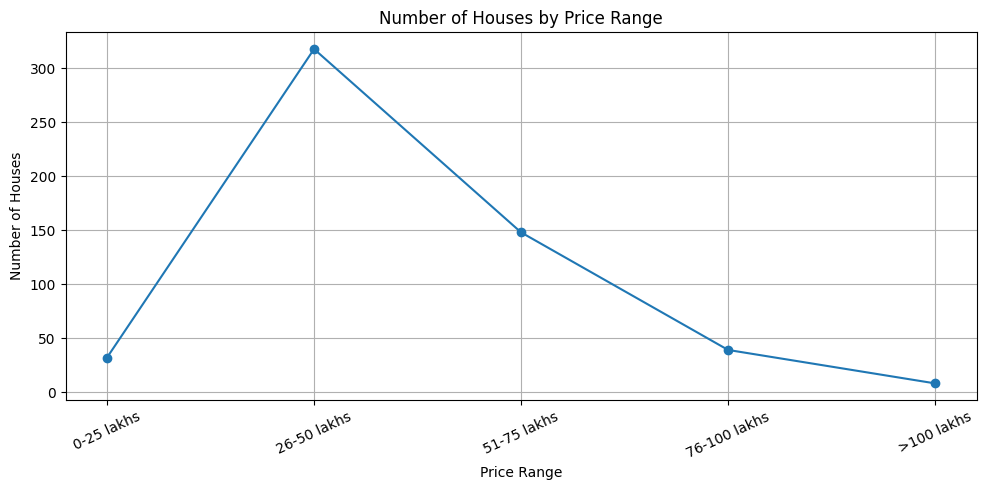

In [4]:
# Cell 3 — Q1: counts by price range and line chart

# Convert price ranges in rupees:
# 1 lakh = 100000
lakhs = 100000

bins = [0,
        25 * lakhs,   # 2,500,000
        50 * lakhs,   # 5,000,000
        75 * lakhs,   # 7,500,000
        100 * lakhs,  # 10,000,000
        df['price'].max() + 1]
labels = ['0-25 lakhs', '26-50 lakhs', '51-75 lakhs', '76-100 lakhs', '>100 lakhs']

df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True, right=True)
price_counts = df['price_range'].value_counts().reindex(labels)  # keep fixed order

print("Counts by price range:")
print(price_counts)

# Line chart
plt.figure(figsize=(10,5))
plt.plot(price_counts.index, price_counts.values, marker='o')
plt.title("Number of Houses by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Houses")
plt.xticks(rotation=25)
plt.grid(True)
plt.tight_layout()
plt.show()


Average prices by airconditioning (in rupees):
airconditioning_clean
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64


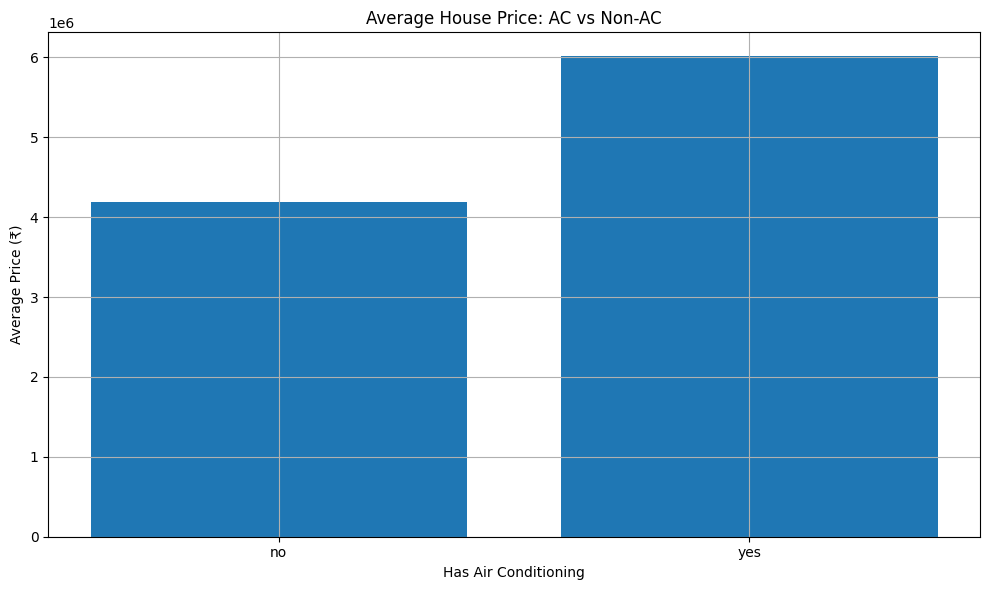


Average prices (in lakhs):
airconditioning_clean
no     41.92
yes    60.13
Name: price, dtype: float64


In [5]:
# Cell 4 — Q2: average price for AC vs Non-AC and bar chart

# Ensure 'airconditioning' column exists and values standardized
if 'airconditioning' not in df.columns:
    raise Exception("Column 'airconditioning' not found. Check CSV column names and re-run after renaming.")

# normalize 'yes'/'no' values
df['airconditioning_clean'] = df['airconditioning'].astype(str).str.strip().str.lower().map(
    lambda x: 'yes' if x in ['yes','y','true','1'] else ('no' if x in ['no','n','false','0'] else x)
)

ac_avg = df.groupby('airconditioning_clean')['price'].mean().sort_index()
print("Average prices by airconditioning (in rupees):")
print(ac_avg)

# Bar chart
plt.figure()
plt.bar(ac_avg.index, ac_avg.values)
plt.title("Average House Price: AC vs Non-AC")
plt.xlabel("Has Air Conditioning")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Also show averages in lakhs for readability
print("\nAverage prices (in lakhs):")
print((ac_avg / lakhs).round(2))


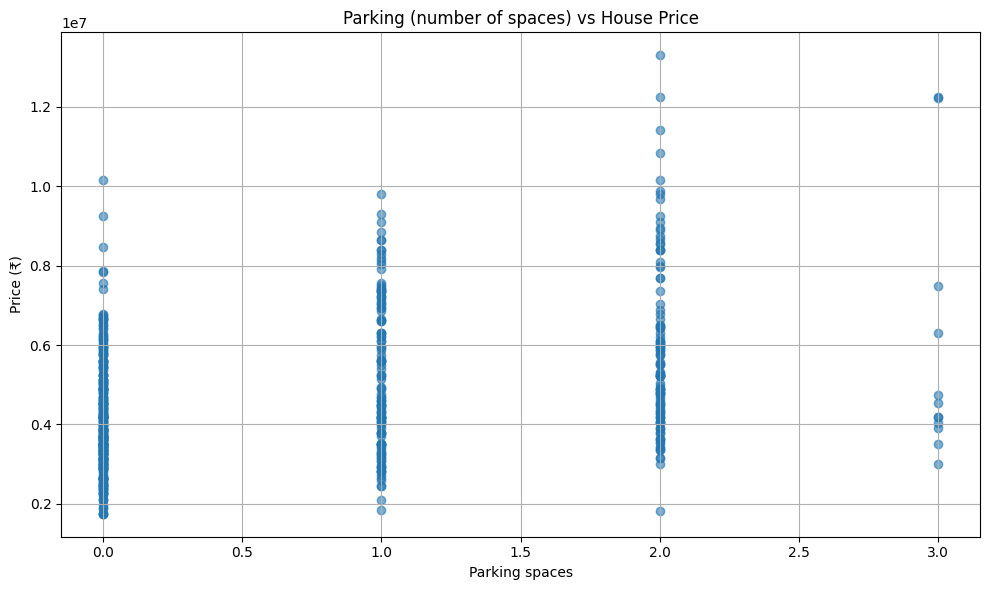

Pearson correlation between parking and price: 0.3844


/tmp/ipython-input-3694138930.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


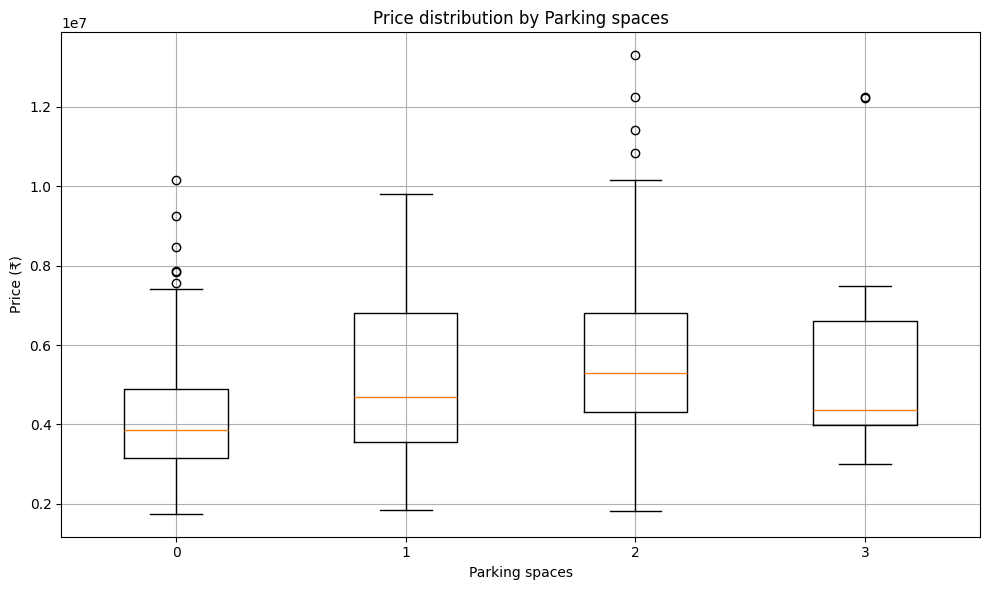

In [6]:
# Cell 5 — Q3: parking vs price (scatter + correlation + boxplot)

if 'parking' not in df.columns:
    raise Exception("Column 'parking' not found. Check CSV column names and re-run after renaming.")

# Convert parking to numeric if necessary (some datasets have '2' as int or '2 ' as string)
df['parking_num'] = pd.to_numeric(df['parking'], errors='coerce')

# Scatter plot
plt.figure()
plt.scatter(df['parking_num'], df['price'], alpha=0.6)
plt.title("Parking (number of spaces) vs House Price")
plt.xlabel("Parking spaces")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation
corr = df[['parking_num', 'price']].dropna().corr().iloc[0,1]
print("Pearson correlation between parking and price:", round(corr, 4))

# Boxplot of price grouped by parking count (to see distribution)
plt.figure()
df_box = df[['parking_num', 'price']].dropna()
groups = [g['price'].values for _, g in df_box.groupby('parking_num')]
labels = sorted(df_box['parking_num'].unique().tolist())
plt.boxplot(groups, labels=labels)
plt.title("Price distribution by Parking spaces")
plt.xlabel("Parking spaces")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()


Counts: GroupA (<5000 & no prefarea) = 269 , GroupB (>5000 & prefarea) = 91

Mean price Group A (₹): 3827671.56133829
Mean price Group B (₹): 6546807.692307692

Mean price Group A (in lakhs): 38.28
Mean price Group B (in lakhs): 65.47

Price gap (B - A) in ₹: 2719136.130969402
Price gap in lakhs: 27.19
Gap as % of Group A mean: 71.04 %


/tmp/ipython-input-691951174.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['<5000 & no prefarea', '>5000 & prefarea'])


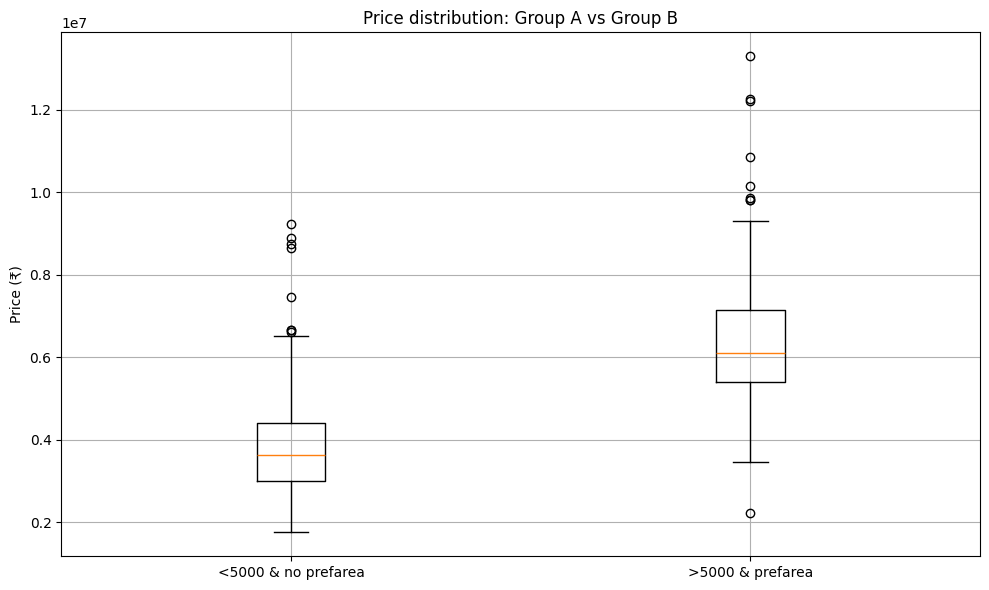

In [7]:
# Cell 6 — Q4: price gap for specific area & prefarea groups

# Ensure area and prefarea exist
if 'area' not in df.columns:
    raise Exception("Column 'area' not found. Check CSV column names and re-run after renaming.")
if 'prefarea' not in df.columns:
    raise Exception("Column 'prefarea' not found. Check CSV column names and re-run after renaming.")

# Clean prefarea column
df['prefarea_clean'] = df['prefarea'].astype(str).str.strip().str.lower().map(
    lambda x: 'yes' if x in ['yes','y','true','1'] else ('no' if x in ['no','n','false','0'] else x)
)

# Convert area to numeric
df['area_num'] = pd.to_numeric(df['area'], errors='coerce')

# Group A: <5000 sqft & no prefarea
groupA = df[(df['area_num'] < 5000) & (df['prefarea_clean']=='no')]
# Group B: >5000 sqft & prefarea yes
groupB = df[(df['area_num'] > 5000) & (df['prefarea_clean']=='yes')]

print("Counts: GroupA (<5000 & no prefarea) =", len(groupA),
      ", GroupB (>5000 & prefarea) =", len(groupB))

meanA = groupA['price'].mean()
meanB = groupB['price'].mean()

print("\nMean price Group A (₹):", meanA)
print("Mean price Group B (₹):", meanB)
print("\nMean price Group A (in lakhs):", round(meanA / lakhs, 2))
print("Mean price Group B (in lakhs):", round(meanB / lakhs, 2))

gap = meanB - meanA
gap_pct = (gap / meanA * 100) if meanA and not np.isnan(meanA) else np.nan
print("\nPrice gap (B - A) in ₹:", gap)
print("Price gap in lakhs:", round(gap / lakhs, 2))
print("Gap as % of Group A mean:", round(gap_pct, 2), "%")

# Optional: show boxplots side by side for visual comparison
plt.figure()
data_to_plot = [groupA['price'].dropna(), groupB['price'].dropna()]
plt.boxplot(data_to_plot, labels=['<5000 & no prefarea', '>5000 & prefarea'])
plt.title("Price distribution: Group A vs Group B")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()


In [8]:
# Cell 7 — quick summary printout + save plots (optional)
print("Summary:")
print("- Counts by price range printed above.")
print("- AC vs Non-AC average printed above.")
print("- Parking vs Price scatter and correlation above.")
print("- Price gap for the two groups printed above.")

# Optional: Save processed dataframe and charts to files and download
df.to_csv('housing_processed.csv', index=False)
print("Processed data saved to housing_processed.csv. Downloading now...")
files.download('housing_processed.csv')  # will start download in browser


Summary:
- Counts by price range printed above.
- AC vs Non-AC average printed above.
- Parking vs Price scatter and correlation above.
- Price gap for the two groups printed above.
Processed data saved to housing_processed.csv. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>